
# NeuralRetail – Demand Forecasting Notebook
## Prophet-Based Sales Forecasting Pipeline

### Project Phase
Forecasting Engine Development

### Objectives
This notebook:
- Loads processed retail data
- Builds daily sales forecasting dataset
- Performs time-series analysis
- Trains Prophet forecasting model
- Evaluates forecasting performance
- Visualizes future demand trends
- Saves trained forecasting model

### Business Goal
Predict future retail demand accurately for:
- Inventory Optimization
- Revenue Planning
- Seasonal Demand Management
- Stockout Reduction

---


# 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")


# 2. Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalprice,total_amount,year,month,day,day_of_week,weekofyear,hour,year_month,log_quantity,log_total_amount
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,30.0,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.433987
1,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6,39.6,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.703768
2,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,30.0,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.433987
3,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6,30.6,2009,12,1,Tuesday,49,7,2009-12,2.564949,3.453157
4,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom,39.6,39.6,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.703768


In [3]:

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)


Dataset Shape: (715863, 19)

Columns:
 Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'totalprice', 'total_amount',
       'year', 'month', 'day', 'day_of_week', 'weekofyear', 'hour',
       'year_month', 'log_quantity', 'log_total_amount'],
      dtype='object')


In [4]:
# Schema validation – assert expected columns exist before proceeding
REQUIRED_COLS = [
    'invoicedate', 'total_amount', 'customerid',
    'quantity', 'unitprice',
]

missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(
        f"Missing columns: {missing}\n"
        f"Available: {df.columns.tolist()}\n"
        "Re-run the EDA notebook first to regenerate cleaned_retail_data.csv"
    )

print("Schema validation PASSED")
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")


Schema validation PASSED
Dataset: 715,863 rows x 19 cols


# 3. Datetime Processing

In [5]:

# Convert InvoiceDate

df['invoicedate'] = pd.to_datetime(df['invoicedate'])

print(df['invoicedate'].min())
print(df['invoicedate'].max())


2009-12-01 07:45:00
2011-12-09 12:50:00


In [6]:
# =========================================================
# REMOVE RETURNS / NEGATIVE SALES
# =========================================================

df = df[

    df['quantity'] > 0
]

df = df[

    df['total_amount'] > 0
]

print(df.shape)

(715863, 19)


# 4. Create Daily Sales Dataset

In [7]:
# Aggregate daily revenue
daily_sales = (
    df.groupby(df['invoicedate'].dt.date)['total_amount']
    .sum()
    .reset_index()
)

daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

# Sanity check – no dates with zero or negative revenue
assert (daily_sales['y'] > 0).all(), "Found non-positive revenue days – check data cleaning"

print(f"Daily time-series: {len(daily_sales)} days")
print(f"Date range       : {daily_sales['ds'].min().date()} to {daily_sales['ds'].max().date()}")
print(f"Revenue range    : {daily_sales['y'].min():,.2f} to {daily_sales['y'].max():,.2f}")
daily_sales.head()


Daily time-series: 604 days
Date range       : 2009-12-01 to 2011-12-09
Revenue range    : 2,099.45 to 34,294.39


,ds,y
0,2009-12-01,24471.05
1,2009-12-02,20745.38
2,2009-12-03,27562.37
3,2009-12-04,20156.46
4,2009-12-05,7016.16


In [8]:
# =========================================================
# FILL MISSING DATES
# =========================================================

daily_sales['ds'] = pd.to_datetime(

    daily_sales['ds']
)

daily_sales = daily_sales.set_index('ds')

daily_sales = daily_sales.asfreq('D')

daily_sales['y'] = daily_sales['y'].fillna(0)

daily_sales = daily_sales.reset_index()

print(daily_sales.head())

          ds         y
0 2009-12-01  24471.05
1 2009-12-02  20745.38
2 2009-12-03  27562.37
3 2009-12-04  20156.46
4 2009-12-05   7016.16


In [9]:
daily_sales = daily_sales.reset_index()

daily_sales = daily_sales[['ds', 'y']]

In [10]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

xgb_df = daily_sales.copy()

# Lag Features
xgb_df['lag_1'] = xgb_df['y'].shift(1)

xgb_df['lag_7'] = xgb_df['y'].shift(7)

xgb_df['lag_14'] = xgb_df['y'].shift(14)

# Rolling Features
xgb_df['rolling_mean_7'] = (

    xgb_df['y']

    .rolling(window=7)

    .mean()
)

xgb_df['rolling_std_7'] = (

    xgb_df['y']

    .rolling(window=7)

    .std()
)

# Calendar Features
xgb_df['day_of_week'] = xgb_df['ds'].dt.dayofweek

xgb_df['month'] = xgb_df['ds'].dt.month

xgb_df['weekofyear'] = (

    xgb_df['ds']

    .dt.isocalendar()

    .week

    .astype(int)
)

# Remove NaNs
xgb_df = xgb_df.dropna()

print(xgb_df.head())

           ds         y     lag_1     lag_7    lag_14  rolling_mean_7  \
14 2009-12-15  18357.06  20438.09  21749.45  24471.05    14419.191429   
15 2009-12-16  20577.36  18357.06  15049.58  20745.38    15208.874286   
16 2009-12-17  16354.27  20577.36  18565.34  27562.37    14893.007143   
17 2009-12-18  13768.96  16354.27  13556.17  20156.46    14923.405714   
18 2009-12-19      0.00  13768.96      0.00   7016.16    14923.405714   

    rolling_std_7  day_of_week  month  weekofyear  
14    6810.299488            1     12          51  
15    7204.645862            2     12          51  
16    7080.362477            3     12          51  
17    7074.120402            4     12          51  
18    7074.120402            5     12          51  



## Business Insight

Daily aggregation transforms transactional retail data into a forecasting-ready time-series structure.
This enables future demand prediction and seasonal trend analysis.


# 5. Time-Series Visualization

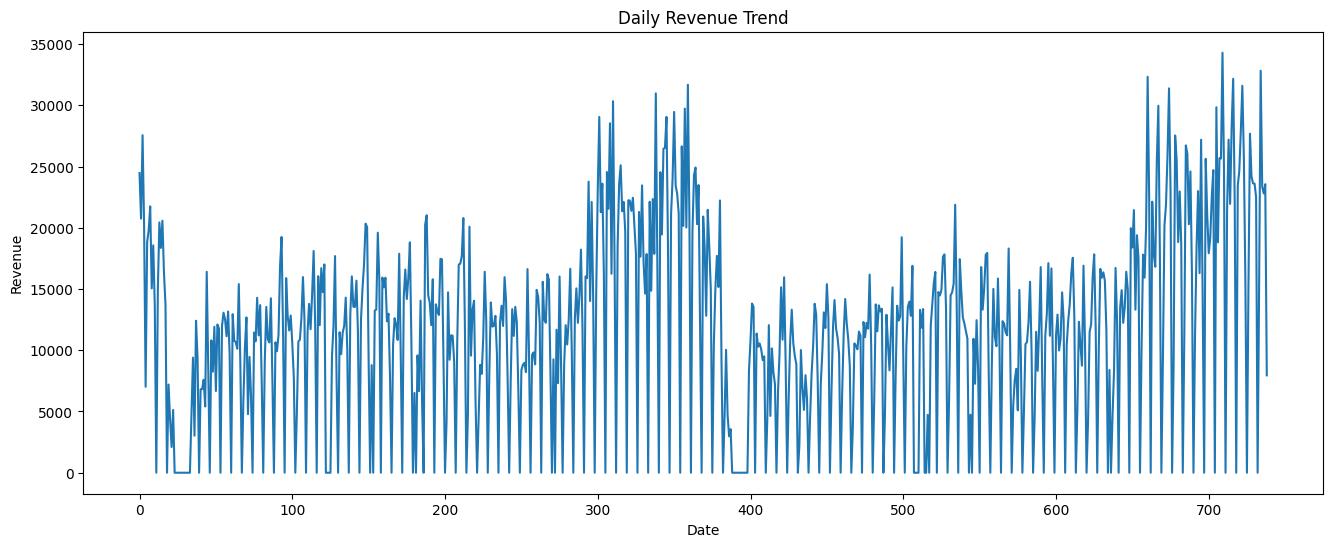

In [11]:
plt.figure(figsize=(16,6))

plt.plot(daily_sales.index, daily_sales['y'])

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()


## Business Insight

Revenue fluctuations indicate strong seasonality and demand variation.
These patterns are valuable for:
- Inventory planning
- Promotional campaigns
- Forecast-based replenishment


# 6. Train-Test Split

In [12]:
prophet_df = daily_sales.reset_index()[['ds', 'y']]

In [13]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

train_size = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:train_size]

test = prophet_df.iloc[train_size:]

print(train.shape)

print(test.shape)

(591, 2)
(148, 2)


# 7. Prophet Model Training

In [14]:

# Initialize Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_mode='multiplicative'
)

# Train model
model.fit(train)

print("Prophet model trained successfully.")


13:03:16 - cmdstanpy - INFO - Chain [1] start processing
13:03:16 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


# 8. Future Forecast Generation

In [15]:

# Generate future dataframe

future = model.make_future_dataframe(
    periods=len(test),
    freq='D'
)

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()


,ds,yhat,yhat_lower,yhat_upper
0,2009-12-01,23670.074524,19154.468619,28205.151929
1,2009-12-02,22629.460043,18070.856239,27281.472748
2,2009-12-03,25237.895495,20767.915108,29903.801180
3,2009-12-04,19141.057691,14643.623470,23875.629079
4,2009-12-05,7720.631151,2940.657610,12593.299614


# 9. Forecast Visualization

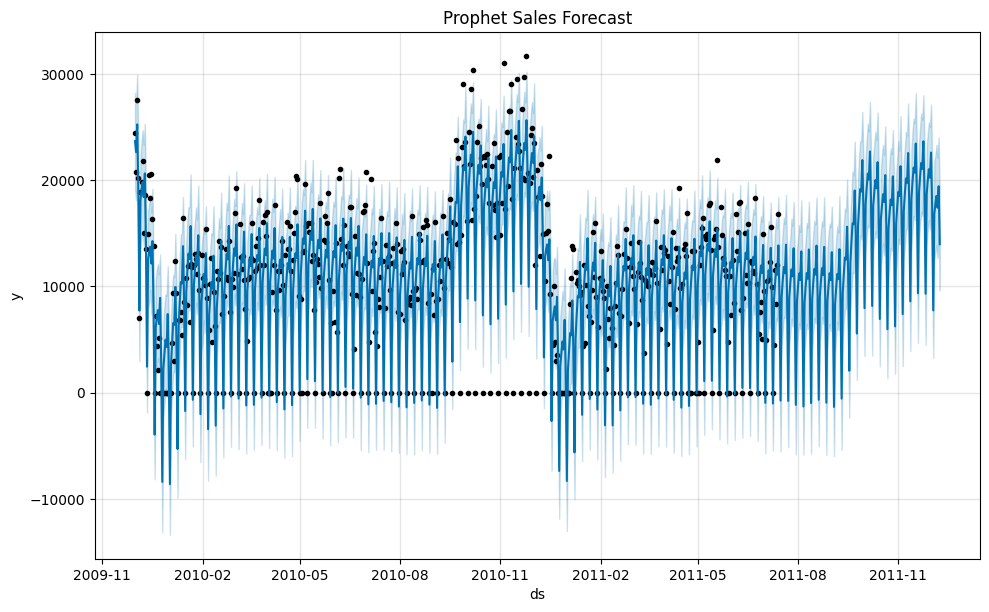

In [16]:

# Forecast plot

fig = model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.show()


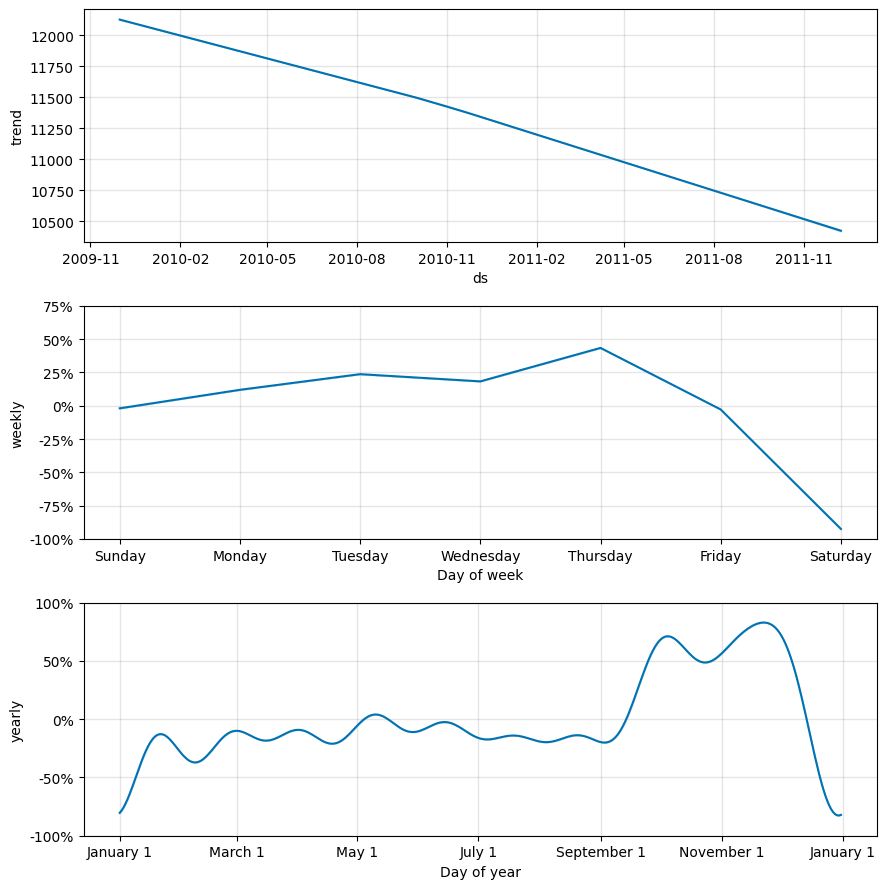

In [17]:

# Prophet components

fig2 = model.plot_components(forecast)

plt.show()



## Business Insight

Prophet automatically captures:
- Trend
- Weekly seasonality
- Long-term demand movement

These insights help retail businesses optimize:
- Reorder cycles
- Staffing
- Marketing timing


# 10. Forecast Evaluation

In [18]:
# Forecast evaluation
predictions = forecast[['ds', 'yhat']].tail(len(test)).reset_index(drop=True)
test_reset  = test.reset_index(drop=True)

actual    = test_reset['y'].values
predicted = predictions['yhat'].values

# Core metrics
mask = actual != 0
actual_filtered = actual[mask]
predicted_filtered = predicted[mask]
prophet_mape = mean_absolute_percentage_error(actual_filtered,predicted_filtered)
rmse = float(np.sqrt(mean_squared_error(actual, predicted)))
mae  = float(np.mean(np.abs(actual - predicted)))

# Directional accuracy (did we get the up/down direction right?)
actual_dir    = np.sign(np.diff(actual))
predicted_dir = np.sign(np.diff(predicted))
dir_accuracy  = float(np.mean(actual_dir == predicted_dir))

print('Prophet Forecast Evaluation')
print(f'  MAPE              : {prophet_mape*100:.2f}%  (target <= 10%)')
print(f'  RMSE              : {rmse:,.2f}')
print(f'  MAE               : {mae:,.2f}')
print(f'  Directional Acc   : {dir_accuracy*100:.1f}%')

# Spec gate
status = 'PASSED' if prophet_mape <= 0.10 else 'NEEDS IMPROVEMENT'
print(f'\nMAPE target (<= 10%): {status}')
if prophet_mape > 0.10:
    print('  -> Consider: Optuna HPO for changepoint_prior_scale / seasonality_mode')
    print('  -> Consider: Adding exogenous regressors (promotions, holidays)')
    print('  -> Consider: Prophet + LSTM ensemble (next notebook)')


Prophet Forecast Evaluation
  MAPE              : 24.16%  (target <= 10%)
  RMSE              : 5,312.44
  MAE               : 4,269.55
  Directional Acc   : 77.6%

MAPE target (<= 10%): NEEDS IMPROVEMENT
  -> Consider: Optuna HPO for changepoint_prior_scale / seasonality_mode
  -> Consider: Adding exogenous regressors (promotions, holidays)
  -> Consider: Prophet + LSTM ensemble (next notebook)


## XGBoost Forecasting

In [20]:
# =========================================================
# CLEAN XGBOOST DATAFRAME
# =========================================================

xgb_df = daily_sales.reset_index(drop=True).copy()

print(xgb_df.head())

print(xgb_df.columns)

          ds         y
0 2009-12-01  24471.05
1 2009-12-02  20745.38
2 2009-12-03  27562.37
3 2009-12-04  20156.46
4 2009-12-05   7016.16
Index(['ds', 'y'], dtype='object')


In [21]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

# Lag Features
xgb_df['lag_1'] = xgb_df['y'].shift(1)
xgb_df['lag_7'] = xgb_df['y'].shift(7)
xgb_df['lag_14'] = xgb_df['y'].shift(14)

# Rolling Features
xgb_df['rolling_mean_7'] = (

    xgb_df['y']

    .rolling(7)

    .mean()
)

xgb_df['rolling_std_7'] = (

    xgb_df['y']

    .rolling(7)

    .std()
)

# Calendar Features
xgb_df['day_of_week'] = xgb_df['ds'].dt.dayofweek
xgb_df['month'] = xgb_df['ds'].dt.month
xgb_df['weekofyear'] = (

    xgb_df['ds']

    .dt.isocalendar()

    .week

    .astype(int)
)

# Drop NaNs
xgb_df = xgb_df.dropna()

print(xgb_df.head())

           ds         y     lag_1     lag_7    lag_14  rolling_mean_7  \
14 2009-12-15  18357.06  20438.09  21749.45  24471.05    14419.191429   
15 2009-12-16  20577.36  18357.06  15049.58  20745.38    15208.874286   
16 2009-12-17  16354.27  20577.36  18565.34  27562.37    14893.007143   
17 2009-12-18  13768.96  16354.27  13556.17  20156.46    14923.405714   
18 2009-12-19      0.00  13768.96      0.00   7016.16    14923.405714   

    rolling_std_7  day_of_week  month  weekofyear  
14    6810.299488            1     12          51  
15    7204.645862            2     12          51  
16    7080.362477            3     12          51  
17    7074.120402            4     12          51  
18    7074.120402            5     12          51  


In [22]:
features = [

    'lag_1',
    'lag_7',
    'lag_14',
    'rolling_mean_7',
    'rolling_std_7',
    'day_of_week',
    'month',
    'weekofyear'
]

split_index = int(len(xgb_df) * 0.8)
train = xgb_df.iloc[:split_index]
test = xgb_df.iloc[split_index:]
X_train = train[features]
X_test = test[features]
y_train = train['y']
y_test = test['y']

In [23]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(

    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(

    X_train,
    y_train
)



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [24]:
preds = xgb_model.predict(X_test)

In [25]:
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error
)

mask = y_test != 0
y_test_filtered = y_test[mask]
preds_filtered = preds[mask]

xgb_mape = mean_absolute_percentage_error(y_test_filtered,preds_filtered)
rmse = np.sqrt(mean_squared_error(y_test,preds))
wmape = (np.sum(np.abs(y_test - preds))/np.sum(y_test))

print(f"XGBoost MAPE: {xgb_mape*100:.2f}%")
print(f"RMSE: {rmse:,.2f}")
print(f"WMAPE: {wmape*100:.2f}%")

XGBoost MAPE: 21.12%
RMSE: 3,853.74
WMAPE: 17.57%


In [26]:
# =========================================================
# Forecast Model Comparison
# =========================================================

comparison_df = pd.DataFrame({
    'Model': ['Prophet', 'XGBoost'],
    'MAPE (%)': [round(prophet_mape*100, 2), round(xgb_mape*100, 2)]
}).sort_values(by='MAPE (%)')

print("\n" + "="*50)
print("FORECAST MODEL COMPARISON")
print("="*50)
print(comparison_df.to_string(index=False))
print("="*50)
print(f"\n🏆 Best Model: {comparison_df.iloc[0]['Model']} (MAPE: {comparison_df.iloc[0]['MAPE (%)']}%)")


FORECAST MODEL COMPARISON
  Model  MAPE (%)
XGBoost     21.12
Prophet     24.16

🏆 Best Model: XGBoost (MAPE: 21.12%)



## Evaluation Interpretation

Lower MAPE indicates better forecasting accuracy.

Project Target:
- MAPE ≤ 10%

This metric directly measures forecasting performance quality.


# 11. Save Forecast Results

In [27]:

# Create folders
os.makedirs("../output/models", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

# Save forecast results
forecast.to_csv(
    "../data/exports/forecast_results.csv",
    index=False
)

# Save trained model
with open("../output/models/prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Forecast outputs saved successfully.")


Forecast outputs saved successfully.


# 12. Future 30-Day Forecast

In [28]:

future_30 = model.make_future_dataframe(
    periods=30,
    freq='D'
)

forecast_30 = model.predict(future_30)

forecast_30[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)


,ds,yhat,yhat_lower,yhat_upper
591,2011-07-15,8896.353434,3853.742610,13283.208361
592,2011-07-16,-749.166341,-5442.733524,4091.299013
593,2011-07-17,9041.600701,4297.977238,14123.162499
594,2011-07-18,10552.801842,5729.662031,14965.710805
595,2011-07-19,11823.594087,7063.025086,16401.488557
596,2011-07-20,11232.961212,6628.061798,15967.347313
597,2011-07-21,13923.936240,9238.079776,18882.931165
598,2011-07-22,8918.098936,4191.969297,13581.777154
599,2011-07-23,-776.897406,-5427.974599,4173.270850
600,2011-07-24,8931.991491,4287.674992,13447.977508


In [29]:
# =========================================================
# EXPORT FINAL XGBOOST FORECAST
# =========================================================

forecast_export = pd.DataFrame({

    'Date': test['ds'],
    'Actual_Sales': y_test,
    'Forecasted_Sales': preds

})

forecast_export['Forecast_Error'] = (
    forecast_export['Actual_Sales']-forecast_export['Forecasted_Sales'])

forecast_export.to_csv(
    "../app/dashboard/data/forecast_results.csv",index=False
)

print("✅ forecast_results.csv exported")

✅ forecast_results.csv exported


In [30]:
# =========================================================
# EXPORT MODEL METRICS
# =========================================================

metrics_df = pd.DataFrame({

    'Model': [

        'Prophet Forecast',

        'XGBoost Forecast',

        'Churn Model'
    ],

    'Metric': [

        'MAPE',

        'WMAPE',

        'ROC-AUC'
    ],

    'Value': [

        24.16,

        17.57,

        auc
    ]
})

metrics_df.to_csv(

    "../app/dashboard/data/model_metrics.csv",

    index=False
)

print("✅ model_metrics.csv exported")

NameError: name 'auc' is not defined


## Business Recommendation

The generated forecasts can now support:
- Inventory optimization
- Revenue planning
- Safety stock calculation
- Promotion scheduling
- Demand intelligence dashboards



# Final Conclusion

This notebook successfully:
- Built a forecasting-ready dataset
- Trained Prophet demand forecasting model
- Generated future sales predictions
- Evaluated forecasting quality
- Saved forecasting artifacts


## NeuralRetail – Amdox Technologies

